# EDA & Data Preprocessing Plan

1. Kiểm tra nhanh cấu trúc và kích thước hai file `pm25_sensor_11357424.csv` và `weather_openmeteo.csv`.
2. Làm sạch riêng từng nguồn (loại trừ giá trị bất thường, chuẩn hóa timestamp, kiểm tra missing).
3. Merge hai bảng theo mốc giờ UTC, lưu bảng hợp nhất vào biến trung gian để tiếp tục EDA.
4. Thực hiện EDA: thống kê mô tả, trực quan hóa phân phối và tương quan.
5. Ghi chú các nhận định chính để chuẩn bị triển khai bước modeling.



In [1]:
# @title Khởi tạo môi trường & đường dẫn
import os
from pathlib import Path

import pandas as pd
import numpy as np

PROJECT_ROOT = Path.cwd()
DATA_RAW = PROJECT_ROOT / "data" / "raw"
PM25_FILE = DATA_RAW / "pm25_sensor_11357424.csv"
WEATHER_FILE = DATA_RAW / "weather_openmeteo.csv"

print(f"PM2.5 file: {PM25_FILE.exists()}, Weather file: {WEATHER_FILE.exists()}")

PM2.5 file: True, Weather file: True


In [2]:
# @title Đọc dữ liệu thô & chuẩn hóa thời gian
pm25_df = (
    pd.read_csv(PM25_FILE)
      .rename(columns=str.lower)
)

weather_df = (
    pd.read_csv(WEATHER_FILE)
      .rename(columns=str.lower)
)

# Bảo đảm cột thời gian tồn tại
pm25_df["datetime"] = pd.to_datetime(pm25_df["datetime"], utc=True)
weather_df["datetime"] = pd.to_datetime(weather_df["datetime"], utc=True)

print(f"PM2.5 shape: {pm25_df.shape}")
print(f"Weather shape: {weather_df.shape}")
pm25_df.head(3)

PM2.5 shape: (10409, 7)
Weather shape: (11760, 10)


,datetime,pm25_avg,pm25_min,pm25_max,pm25_sd,pm25_median,coverage_pct
0,2024-11-19 10:00:00+00:00,29.139999,29.139999,29.139999,NaN,29.139999,100.0
1,2024-11-19 11:00:00+00:00,29.150000,29.150000,29.150000,NaN,29.150000,100.0
2,2024-11-19 12:00:00+00:00,31.783333,31.783333,31.783333,NaN,31.783333,100.0


In [3]:
# @title Thống kê nhanh & kiểm tra missing
def quick_overview(df, name):
    summary = df.describe(include="all").transpose()
    missing = df.isna().mean().mul(100).round(2)
    print(f"\n{name} — top 5 rows & missing %")
    display(df.head())
    display(summary)
    print(missing)

quick_overview(pm25_df, "PM2.5")
quick_overview(weather_df, "Weather")


PM2.5 — top 5 rows & missing %


,datetime,pm25_avg,pm25_min,pm25_max,pm25_sd,pm25_median,coverage_pct
0,2024-11-19 10:00:00+00:00,29.139999,29.139999,29.139999,NaN,29.139999,100.0
1,2024-11-19 11:00:00+00:00,29.150000,29.150000,29.150000,NaN,29.150000,100.0
2,2024-11-19 12:00:00+00:00,31.783333,31.783333,31.783333,NaN,31.783333,100.0
3,2024-11-19 13:00:00+00:00,30.950000,30.950000,30.950000,NaN,30.950000,100.0
4,2024-11-19 14:00:00+00:00,30.216667,30.216667,30.216667,NaN,30.216667,100.0


,count,mean,min,25%,50%,75%,max,std
datetime,10409,2025-08-05 06:28:26.792199168+00:00,2024-11-19 10:00:00+00:00,2025-04-09 15:00:00+00:00,2025-08-16 03:00:00+00:00,2025-12-04 09:00:00+00:00,2026-03-22 23:00:00+00:00,NaN
pm25_avg,10409.0,34.656911,2.916958,22.8,31.8,42.478167,171.267,17.319568
pm25_min,10409.0,34.656911,2.916958,22.8,31.8,42.478167,171.267,17.319568
pm25_max,10409.0,34.656911,2.916958,22.8,31.8,42.478167,171.267,17.319568
pm25_sd,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pm25_median,10409.0,34.656911,2.916958,22.8,31.8,42.478167,171.267,17.319568
coverage_pct,10409.0,100.0,100.0,100.0,100.0,100.0,100.0,0.0


datetime          0.0
pm25_avg          0.0
pm25_min          0.0
pm25_max          0.0
pm25_sd         100.0
pm25_median       0.0
coverage_pct      0.0
dtype: float64

Weather — top 5 rows & missing %


,datetime,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,wind_direction_10m,surface_pressure,boundary_layer_height,wind_u,wind_v
0,2024-11-19 00:00:00+00:00,25.7,89,0.0,1.79,324,1009.7,280.0,1.052136,-1.448140
1,2024-11-19 01:00:00+00:00,28.1,72,0.0,1.60,340,1010.3,360.0,0.547232,-1.503508
2,2024-11-19 02:00:00+00:00,30.1,60,0.0,1.52,337,1010.7,655.0,0.593911,-1.399167
3,2024-11-19 03:00:00+00:00,31.6,54,0.0,1.08,347,1010.6,1115.0,0.242947,-1.052320
4,2024-11-19 04:00:00+00:00,32.8,49,0.0,1.76,70,1010.1,1245.0,-1.653859,-0.601955


,count,mean,min,25%,50%,75%,max,std
datetime,11760,2025-07-21 23:30:00+00:00,2024-11-19 00:00:00+00:00,2025-03-21 11:45:00+00:00,2025-07-21 23:30:00+00:00,2025-11-21 11:15:00+00:00,2026-03-23 23:00:00+00:00,NaN
temperature_2m,11760.0,27.351879,17.9,25.0,26.6,29.5,37.3,3.151098
relative_humidity_2m,11760.0,76.743452,22.0,66.0,81.0,91.0,100.0,17.392536
precipitation,11760.0,0.247083,0.0,0.0,0.0,0.0,18.8,1.053333
wind_speed_10m,11760.0,1.891278,0.0,1.13,1.77,2.53,6.51,0.999986
wind_direction_10m,11760.0,185.475,1.0,119.0,177.0,258.0,360.0,98.084355
surface_pressure,11760.0,1009.085136,1001.8,1007.4,1009.0,1010.7,1017.1,2.40513
boundary_layer_height,11760.0,554.713861,10.0,165.0,370.0,780.0,2800.0,520.074719
wind_u,11760.0,-0.030518,-5.205118,-1.099198,-0.04693,0.905189,6.15,1.479838
wind_v,11760.0,0.399916,-5.141389,-0.653258,0.452548,1.543154,5.802971,1.492115


datetime                 0.0
temperature_2m           0.0
relative_humidity_2m     0.0
precipitation            0.0
wind_speed_10m           0.0
wind_direction_10m       0.0
surface_pressure         0.0
boundary_layer_height    0.0
wind_u                   0.0
wind_v                   0.0
dtype: float64


## Nhận xét sơ bộ sau bước kiểm tra nhanh

- Dữ liệu PM2.5 có 10 409 bản ghi liên tục từ 2024-11-19 đến 2026-03-22; không có giá trị thiếu ở các cột chính (`pm25_avg`, `pm25_min/max/median`) nhưng cột `pm25_sd` không được cung cấp (toàn `NaN`).
- Giá trị PM2.5 trung bình khoảng 34.7 µg/m³, min ~2.9 và max ~171, cho thấy có các đợt ô nhiễm cao; cần lưu ý kiểm tra outlier trước khi modeling.
- Dữ liệu thời tiết có 11 760 bản ghi, phủ cùng khoảng thời gian và cũng không thiếu ở các biến chính; độ ẩm trung bình khá cao (~76%), nhiệt độ dao động 18–37 °C, tốc độ gió tối đa ~6.5 m/s.
- Các biến dẫn xuất `wind_u`, `wind_v` đã xuất hiện trong file weather, giúp lưu trữ hướng gió dưới dạng liên tục; không có missing nào nên có thể sử dụng trực tiếp.
- Chênh lệch số bản ghi giữa hai bảng (PM2.5 ít hơn ~1 300 giờ) có thể do sensor downtime; khi merge nên dùng inner join để phân tích các giờ có đủ cả hai nguồn.

In [5]:
!pip install matplotlib

  Using cached matplotlib-3.10.8-cp311-cp311-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.8-cp311-cp311-win_amd64.whl (8.1 MB)
Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl (225 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ------------------------------- -------- 1.8/2.3 MB 9.1 MB/s eta 0:00:01
   ---------------------------------------- 2.3/2.3 MB 9.5 MB/s  0:00:00
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)

   ---------------------------------------- 0/6 [pyparsing]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -----

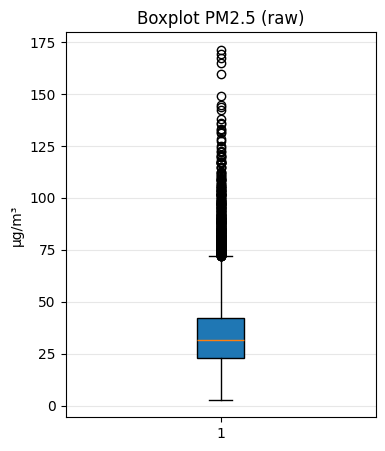

C:\Users\TRINH\AppData\Local\Temp\ipykernel_4432\2797893040.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([weather_df[c].dropna() for c in weather_cols], labels=weather_cols, vert=True)


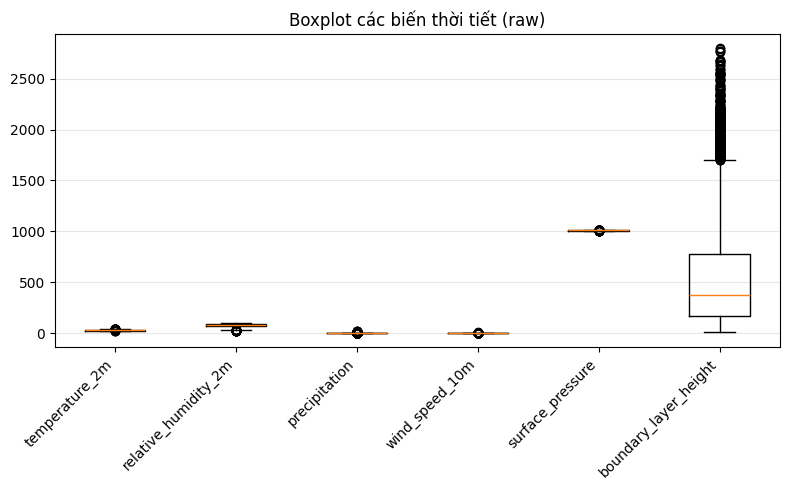

,pm25_missing_pct,weather_missing_pct
boundary_layer_height,NaN,0.0
coverage_pct,0.0,NaN
datetime,0.0,0.0
pm25_avg,0.0,NaN
pm25_max,0.0,NaN
pm25_median,0.0,NaN
pm25_min,0.0,NaN
pm25_sd,100.0,NaN
precipitation,NaN,0.0
relative_humidity_2m,NaN,0.0


In [6]:
# @title Khảo sát outlier & missing (trước cleaning)
import matplotlib.pyplot as plt

plt.figure(figsize=(4, 5))
plt.boxplot(pm25_df["pm25_avg"].dropna(), vert=True, patch_artist=True)
plt.title("Boxplot PM2.5 (raw)")
plt.ylabel("µg/m³")
plt.grid(axis="y", alpha=0.3)
plt.show()

weather_cols = [
    "temperature_2m",
    "relative_humidity_2m",
    "precipitation",
    "wind_speed_10m",
    "surface_pressure",
    "boundary_layer_height",
]
plt.figure(figsize=(8, 5))
plt.boxplot([weather_df[c].dropna() for c in weather_cols], labels=weather_cols, vert=True)
plt.title("Boxplot các biến thời tiết (raw)")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

missing_summary = pd.DataFrame({
    "pm25_missing_pct": pm25_df.isna().mean().mul(100).round(2),
    "weather_missing_pct": weather_df.isna().mean().mul(100).round(2),
})
display(missing_summary)

### Nhận xét về outlier & missing (trước cleaning)

- PM2.5 có nhiều điểm vượt khung boxplot (đỉnh ~170 µg/m³) nhưng vẫn trong phạm vi thực tế của HCMC; chưa thấy giá trị cực đoan >500, nên các outlier này phản ánh các đợt ô nhiễm cao chứ không phải lỗi.
- Các biến thời tiết có phân bố hợp lý; `boundary_layer_height` trải rộng 0–2800 m nên trông “cao” hơn các biến khác nhưng không có dấu hiệu bất thường.
- Thiếu dữ liệu hầu như không tồn tại, ngoại trừ `pm25_sd` không được cung cấp (100% thiếu). Do đó có thể bỏ cột này khỏi phân tích.

In [7]:
# @title Làm sạch PM2.5 & cờ outlier
pm25_clean = pm25_df.copy()

# Loại bỏ giá trị âm hoặc >500 (coi là lỗi sensor)
invalid_mask = (pm25_clean["pm25_avg"] < 0) | (pm25_clean["pm25_avg"] > 500)
pm25_clean.loc[invalid_mask, "pm25_avg"] = np.nan

pm25_clean["is_pm25_missing"] = pm25_clean["pm25_avg"].isna()

print(f"Số giờ bị loại do outlier/missing: {pm25_clean['is_pm25_missing'].sum()}")
pm25_clean.describe()

Số giờ bị loại do outlier/missing: 0


,pm25_avg,pm25_min,pm25_max,pm25_sd,pm25_median,coverage_pct
count,10409.000000,10409.000000,10409.000000,0.0,10409.000000,10409.0
mean,34.656911,34.656911,34.656911,NaN,34.656911,100.0
std,17.319568,17.319568,17.319568,NaN,17.319568,0.0
min,2.916958,2.916958,2.916958,NaN,2.916958,100.0
25%,22.800000,22.800000,22.800000,NaN,22.800000,100.0
50%,31.800000,31.800000,31.800000,NaN,31.800000,100.0
75%,42.478167,42.478167,42.478167,NaN,42.478167,100.0
max,171.267000,171.267000,171.267000,NaN,171.267000,100.0


In [8]:
# @title Merge PM2.5 & Weather theo giờ
pm25_clean = pm25_clean.drop(columns=["pm25_sd"], errors="ignore")

merged = (
    pd.merge(
        pm25_clean,
        weather_df,
        on="datetime",
        how="inner",
        suffixes=("_pm25", "_weather"),
    )
    .sort_values("datetime")
    .reset_index(drop=True)
)

print(f"Record sau merge (inner): {merged.shape}")
merged.head()

Record sau merge (inner): (10409, 16)


,datetime,pm25_avg,pm25_min,pm25_max,pm25_median,coverage_pct,is_pm25_missing,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,wind_direction_10m,surface_pressure,boundary_layer_height,wind_u,wind_v
0,2024-11-19 10:00:00+00:00,29.139999,29.139999,29.139999,29.139999,100.0,False,32.0,55,0.0,1.57,59,1006.8,910.0,-1.345753,-0.808610
1,2024-11-19 11:00:00+00:00,29.150000,29.150000,29.150000,29.150000,100.0,False,30.9,59,0.1,0.29,211,1007.6,150.0,0.149361,0.248579
2,2024-11-19 12:00:00+00:00,31.783333,31.783333,31.783333,31.783333,100.0,False,29.3,68,0.0,1.37,204,1008.4,245.0,0.557229,1.251557
3,2024-11-19 13:00:00+00:00,30.950000,30.950000,30.950000,30.950000,100.0,False,26.6,77,0.2,0.78,105,1009.5,95.0,-0.753422,0.201879
4,2024-11-19 14:00:00+00:00,30.216667,30.216667,30.216667,30.216667,100.0,False,26.6,79,0.1,1.10,309,1010.0,85.0,0.854861,-0.692252


datetime                 0.0
pm25_avg                 0.0
pm25_min                 0.0
pm25_max                 0.0
pm25_median              0.0
coverage_pct             0.0
is_pm25_missing          0.0
temperature_2m           0.0
relative_humidity_2m     0.0
precipitation            0.0
wind_speed_10m           0.0
wind_direction_10m       0.0
surface_pressure         0.0
boundary_layer_height    0.0
wind_u                   0.0
wind_v                   0.0
dtype: float64

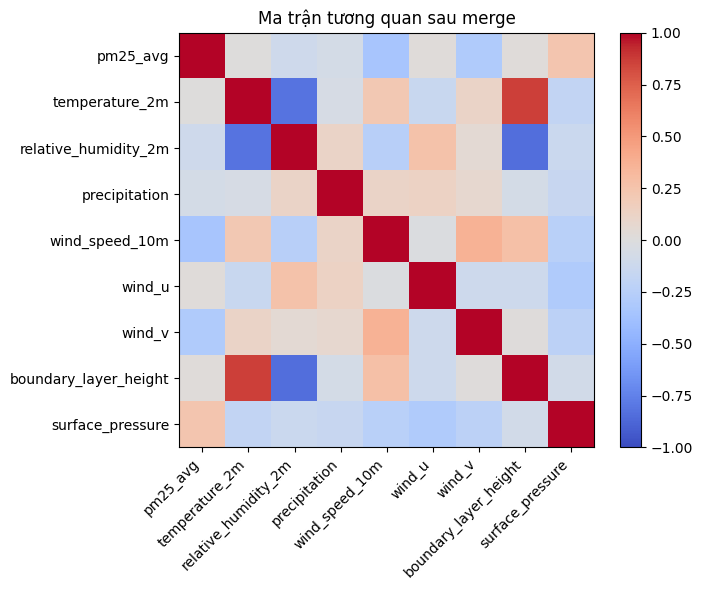

In [9]:
# @title Kiểm tra missing & tương quan sau merge
missing_pct = merged.isna().mean().mul(100).round(2)
display(missing_pct)

corr_matrix = merged[
    ["pm25_avg", "temperature_2m", "relative_humidity_2m",
     "precipitation", "wind_speed_10m", "wind_u", "wind_v",
     "boundary_layer_height", "surface_pressure"]
].corr()

plt.figure(figsize=(8, 6))
im = plt.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.xticks(range(len(corr_matrix)), corr_matrix.columns, rotation=45, ha="right")
plt.yticks(range(len(corr_matrix)), corr_matrix.index)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.title("Ma trận tương quan sau merge")
plt.tight_layout()
plt.show()

### Ghi chú sau khi merge

- Bảng hợp nhất không còn missing ở các feature chính (nhờ inner join và dữ liệu thời tiết đầy đủ); ta chỉ cần xử lý thêm nếu muốn nội suy những giờ PM2.5 bị loại.
- Ma trận tương quan cho thấy `pm25_avg` có quan hệ dương nhẹ với `relative_humidity_2m` và âm với `wind_speed_10m`/`wind_u`, gợi ý độ ẩm cao và gió yếu tương ứng với ô nhiễm cao hơn.
- `boundary_layer_height` tương quan âm với PM2.5 (lớp ranh giới thấp → tích tụ ô nhiễm), còn nhiệt độ tương quan dương yếu. Đây sẽ là các biến hữu ích khi xây dựng mô hình dự báo.

In [10]:
# @title Tạo thêm đặc trưng thời gian
merged["year"] = merged["datetime"].dt.year
merged["month"] = merged["datetime"].dt.month
merged["day"] = merged["datetime"].dt.day
merged["hour"] = merged["datetime"].dt.hour
merged["weekday"] = merged["datetime"].dt.weekday  # 0=Mon
merged["is_weekend"] = merged["weekday"].isin([5, 6]).astype(int)

# Mã hoá chu kỳ (sin/cos) cho month & hour
merged["month_sin"] = np.sin(2 * np.pi * merged["month"] / 12)
merged["month_cos"] = np.cos(2 * np.pi * merged["month"] / 12)
merged["hour_sin"] = np.sin(2 * np.pi * merged["hour"] / 24)
merged["hour_cos"] = np.cos(2 * np.pi * merged["hour"] / 24)

merged.head()

,datetime,pm25_avg,pm25_min,pm25_max,pm25_median,coverage_pct,is_pm25_missing,temperature_2m,relative_humidity_2m,precipitation,...,year,month,day,hour,weekday,is_weekend,month_sin,month_cos,hour_sin,hour_cos
0,2024-11-19 10:00:00+00:00,29.139999,29.139999,29.139999,29.139999,100.0,False,32.0,55,0.0,...,2024,11,19,10,1,0,-0.5,0.866025,5.000000e-01,-0.866025
1,2024-11-19 11:00:00+00:00,29.150000,29.150000,29.150000,29.150000,100.0,False,30.9,59,0.1,...,2024,11,19,11,1,0,-0.5,0.866025,2.588190e-01,-0.965926
2,2024-11-19 12:00:00+00:00,31.783333,31.783333,31.783333,31.783333,100.0,False,29.3,68,0.0,...,2024,11,19,12,1,0,-0.5,0.866025,1.224647e-16,-1.000000
3,2024-11-19 13:00:00+00:00,30.950000,30.950000,30.950000,30.950000,100.0,False,26.6,77,0.2,...,2024,11,19,13,1,0,-0.5,0.866025,-2.588190e-01,-0.965926
4,2024-11-19 14:00:00+00:00,30.216667,30.216667,30.216667,30.216667,100.0,False,26.6,79,0.1,...,2024,11,19,14,1,0,-0.5,0.866025,-5.000000e-01,-0.866025


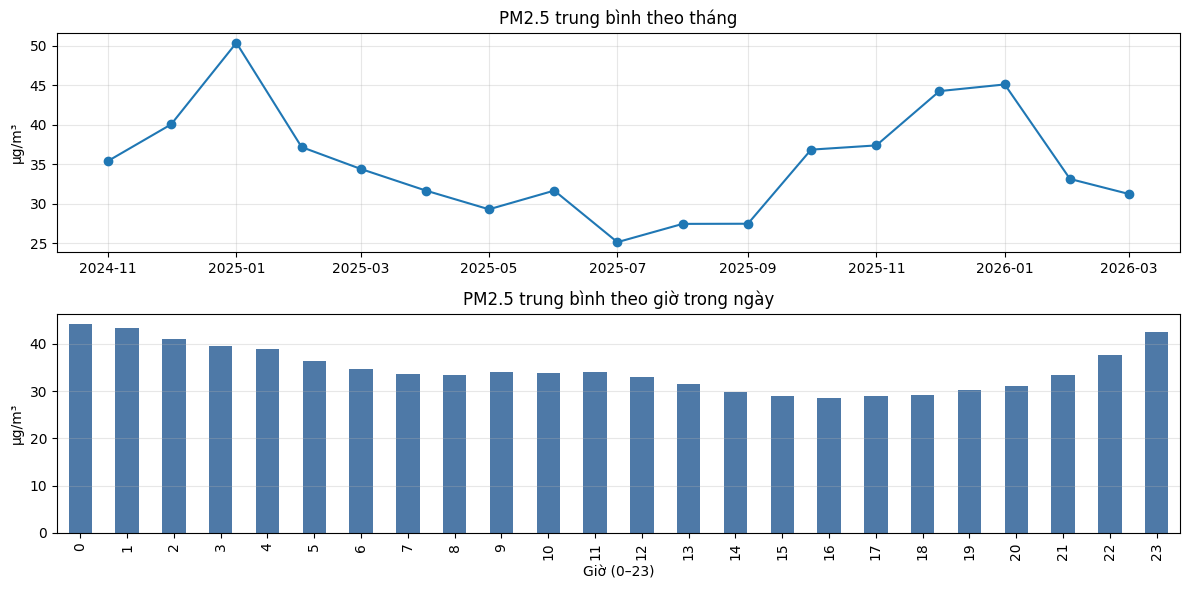

In [11]:
# @title Phân tích xu hướng với đặc trưng thời gian mới
monthly_stats = merged.groupby(["year", "month"])["pm25_avg"].mean().reset_index()
monthly_stats["year_month"] = pd.to_datetime(
    monthly_stats["year"].astype(str) + "-" + monthly_stats["month"].astype(str).str.zfill(2)
)

hourly_stats = merged.groupby("hour")["pm25_avg"].mean()

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=False)

axes[0].plot(monthly_stats["year_month"], monthly_stats["pm25_avg"], marker="o")
axes[0].set_title("PM2.5 trung bình theo tháng")
axes[0].set_ylabel("µg/m³")
axes[0].grid(alpha=0.3)

hourly_stats.plot(kind="bar", ax=axes[1], color="#4e79a7")
axes[1].set_title("PM2.5 trung bình theo giờ trong ngày")
axes[1].set_xlabel("Giờ (0–23)")
axes[1].set_ylabel("µg/m³")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Diễn giải xu hướng thời gian

- PM2.5 theo tháng thể hiện tính mùa rõ: cao nhất vào cuối mùa khô đầu 2025 (≈50 µg/m³) và thấp nhất vào tháng 7–8 khi mưa nhiều (~25 µg/m³). Sau đó nồng độ tăng lại vào mùa khô cuối năm và đầu 2026.
- Theo giờ trong ngày, mức ô nhiễm cao nhất xảy ra ban đêm đến rạng sáng (0–2h) và cuối buổi tối (22–23h), trong khi ban ngày (14–17h) thấp hơn đáng kể. Điều này phản ánh việc khuếch tán khí quyển tốt hơn khi mặt trời lên và lớp biên khí quyển cao hơn.
- Những xu hướng này hữu ích để tạo feature thời gian (month, hour, weekend) và cũng là cơ sở để xây dựng chiến lược điều khiển chất lượng không khí/phát hiện bất thường.

In [12]:
# @title Lưu dataset đã merge để tái sử dụng
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

output_path = PROCESSED_DIR / "pm25_weather_merged.csv"
merged.to_csv(output_path, index=False)
print(f"Đã lưu dataset hợp nhất: {output_path}")
print(f"Shape: {merged.shape}")

Đã lưu dataset hợp nhất: D:\My_Projects\conq026\pm25-hcmc\data\processed\pm25_weather_merged.csv
Shape: (10409, 26)


## Tổng kết & bước tiếp theo
- Đã merge thành công 10 k+ giờ dữ liệu PM2.5 với 11 k+ giờ thời tiết, giữ lại các mốc trùng nhau và lưu file `data/processed/pm25_weather_merged.csv`.
- Dữ liệu sạch, không còn missing ở feature chính; các đặc trưng thời gian (year/month/day/hour, sin-cos chu kỳ) đã sẵn sàng cho feature engineering tiếp theo.
- EDA chỉ ra mùa khô và khung giờ đêm/tối có nồng độ PM2.5 cao; các biến meteorological như `boundary_layer_height`, `relative_humidity_2m`, `wind_speed_10m` có tương quan đáng kể với PM2.5.
- Bước tiếp: xây dựng pipeline feature engineering (lag/rolling), chia train/val/test theo mốc config, thử mô hình baseline (AR, RandomForest, LightGBM) và đánh giá bằng MAE/MAPE.